In [10]:
text=["All that we are is a result of what we have thought","To be or not to be, that is the question","Be yourself, everyone else is already taken"]

import re
re.split('\s',text[0])

['All',
 'that',
 'we',
 'are',
 'is',
 'a',
 'result',
 'of',
 'what',
 'we',
 'have',
 'thought']

In [3]:
' '.join(re.split('\s',text[0]))
allwords=re.split('\s',' '.join(text).lower())
print(allwords)

['all', 'that', 'we', 'are', 'is', 'a', 'result', 'of', 'what', 'we', 'have', 'thought', 'to', 'be', 'or', 'not', 'to', 'be,', 'that', 'is', 'the', 'question', 'be', 'yourself,', 'everyone', 'else', 'is', 'already', 'taken']


In [4]:
vocab=sorted(set(allwords))
print(vocab)
print(len(vocab))
print(len(allwords))

['a', 'all', 'already', 'are', 'be', 'be,', 'else', 'everyone', 'have', 'is', 'not', 'of', 'or', 'question', 'result', 'taken', 'that', 'the', 'thought', 'to', 'we', 'what', 'yourself,']
23
29


In [5]:
word2idx={word:i for i,word in enumerate(vocab)}
idx2word={i:word for i,word in enumerate(vocab)}
print(word2idx)
print(idx2word)

{'a': 0, 'all': 1, 'already': 2, 'are': 3, 'be': 4, 'be,': 5, 'else': 6, 'everyone': 7, 'have': 8, 'is': 9, 'not': 10, 'of': 11, 'or': 12, 'question': 13, 'result': 14, 'taken': 15, 'that': 16, 'the': 17, 'thought': 18, 'to': 19, 'we': 20, 'what': 21, 'yourself,': 22}
{0: 'a', 1: 'all', 2: 'already', 3: 'are', 4: 'be', 5: 'be,', 6: 'else', 7: 'everyone', 8: 'have', 9: 'is', 10: 'not', 11: 'of', 12: 'or', 13: 'question', 14: 'result', 15: 'taken', 16: 'that', 17: 'the', 18: 'thought', 19: 'to', 20: 'we', 21: 'what', 22: 'yourself,'}


In [7]:
import numpy as np

randidx=np.random.randint(0,len(vocab),10)
print(randidx)
print(" ".join([idx2word[i] for i in randidx]))

[16  2 10 19 18 17 22 16 17  9]
that already not to thought the yourself, that the is


In [8]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline 
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [14]:
def encoder(text):
    allwords=re.split('\s',text.lower())
    return [word2idx[word] for word in allwords]

def decoder(idx):
    return " ".join([idx2word[i] for i in idx])

print(decoder(encoder("All that we are is a result of what we have thought")))

all that we are is a result of what we have thought


Visualize Tokens


[1, 16, 20, 3, 9, 0, 14, 11, 21, 20, 8, 18, 19, 4, 12, 10, 19, 5, 16, 9, 17, 13, 4, 22, 7, 6, 9, 2, 15]


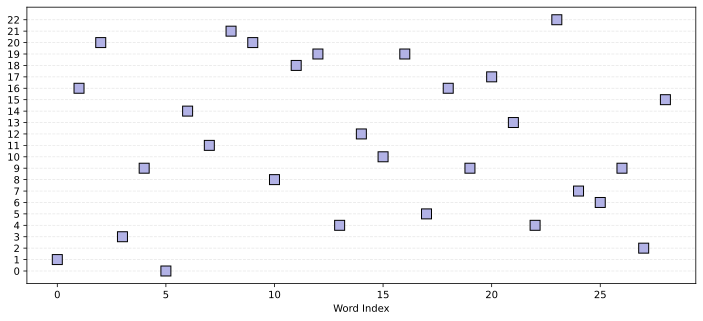

In [25]:
all_text=" ".join(text)
tokens=encoder(all_text)
print(tokens)
_, ax = plt.subplots(1,1, figsize=(12, 5))
ax.plot(tokens,'ks',markersize=10,markerfacecolor=[.7,.7,.9])
ax.set(xlabel="Word Index",yticks=range(len(vocab)))
ax.grid(linestyle='--',alpha=.3,axis='y')
plt.show()


ax2=ax.twinx()
ax2.plot(tokens,alpha=0)
ax2.set(yticks=range(len(vocab)),yticklabels=vocab)

plt.show()

Print indices of a word and its respective  context and target 

In [52]:
target_word="to"
target_locs=np.where(np.array(allwords)==target_word)[0]
print(f"The ordinal positions of target word are: {target_locs}")

print("Printing the context and target for each occurence of the target word:")

for i in target_locs:
    print(tokens[i-1:i+2])
    print(f"Target: {target_word} \n Context: {allwords[i-1]} {allwords[i+1]}")
    

The ordinal positions of target word are: [12 16]
Printing the context and target for each occurence of the target word:
[18, 19, 4]
Target: to 
 Context: thought be
[10, 19, 5]
Target: to 
 Context: not be,


In [54]:
word_matrix=np.zeros((len(allwords),len(vocab)),dtype=int)
for i,word in enumerate(allwords):
    word_matrix[i,word2idx[word]]=1
print(word_matrix)



[[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 

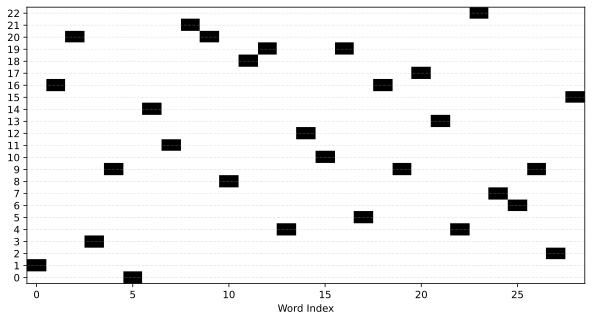

In [62]:
_,ax=plt.subplots(1,1,figsize=(10,5))
plt.imshow(1-word_matrix.T,cmap='gray',origin='lower',aspect='auto')
ax.set(xlabel="Word Index",yticks=range(len(vocab)))
ax.grid(linestyle='--',alpha=.3,axis='y')
plt.show()

In [1]:
import requests
words=requests.get("https://www.gutenberg.org/files/35/35-0.txt")
words=words.text.lower()
words=words.encode('utf-8')
print(type(words))
print(words[:1000])
print(len(words))

<class 'bytes'>
b'*** start of the project gutenberg ebook 35 ***\r\n\r\n\r\n\r\n\r\nthe time machine\r\n\r\nan invention\r\n\r\nby h. g. wells\r\n\r\n\r\ncontents\r\n\r\n i introduction\r\n ii the machine\r\n iii the time traveller returns\r\n iv time travelling\r\n v in the golden age\r\n vi the sunset of mankind\r\n vii a sudden shock\r\n viii explanation\r\n ix the morlocks\r\n x when night came\r\n xi the palace of green porcelain\r\n xii in the darkness\r\n xiii the trap of the white sphinx\r\n xiv the further vision\r\n xv the time traveller\xe2\x80\x99s return\r\n xvi after the story\r\n epilogue\r\n\r\n\r\n\r\n\r\n i.\r\n introduction\r\n\r\n\r\nthe time traveller (for so it will be convenient to speak of him) was\r\nexpounding a recondite matter to us. his pale grey eyes shone and\r\ntwinkled, and his usually pale face was flushed and animated. the fire\r\nburnt brightly, and the soft radiance of the incandescent lights in the\r\nlilies of silver caught the bubbles that flash

In [2]:
print(re.findall(r'\r\n\r\nâ\x80\x9c',words))

NameError: name 're' is not defined

In [ ]:
import re
strings2replace = [
    '\r\n\r\nâ\x80\x9c',  # new paragraph
    'â\x80\x9c',          # open quote

    'â\x80\x9d',          # close quote
    '\r\n',               # new line
    'â\x80\x94',          # hyphen
    'â\x80\x99',          # single apostrophe
    'â\x80\x98',          # single quote
    '_',                  # underscore
]

for item in strings2replace:
    regexp=re.compile("%s"%item)
    words=re.sub(regexp," ",words)

words=re.sub(r'[^00-x7F]+',' ',words)
words=re.sub(r'\s+',' ',words)
words=words.sub(r'[]')
words[:200]




' start of the project gutenberg ebook 35 the time machine an invention b h g wells contents i introduction ii the machine iii the time traveller returns iv time travelling v in the golden age vi the s'

In [ ]:
import string
print(string.punctuation)
punct4re=re.compile(r'[{string.punctuation}\s]+')
words=re.split(punct4re,words)

words


!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


['',
 'f',
 'he',
 'je',
 'e',
 'be',
 'eb',
 'k',
 '35',
 'he',
 'me',
 'm',
 'h',
 'e',
 've',
 'b',
 'h',
 'well',
 'e',
 'd',
 'he',
 'm',
 'h',
 'e',
 'he',
 'me',
 'velle',
 'e',
 'v',
 'me',
 'vell',
 'v',
 'he',
 'lde',
 'e',
 'v',
 'he',
 'e',
 'f',
 'm',
 'k',
 'd',
 'v',
 'dde',
 'h',
 'k',
 'v',
 'ex',
 'l',
 'x',
 'he',
 'm',
 'l',
 'k',
 'x',
 'whe',
 'h',
 'me',
 'x',
 'he',
 'l',
 'e',
 'f',
 'ee',
 'el',
 'x',
 'he',
 'd',
 'k',
 'e',
 'x',
 'he',
 'f',
 'he',
 'wh',
 'e',
 'h',
 'x',
 'x',
 'v',
 'he',
 'f',
 'he',
 'v',
 'xv',
 'he',
 'me',
 'velle',
 'e',
 'xv',
 'f',
 'e',
 'he',
 'e',
 'l',
 'e',
 'd',
 'he',
 'me',
 'velle',
 'f',
 'w',
 'll',
 'be',
 've',
 'e',
 'e',
 'k',
 'f',
 'h',
 'm',
 'w',
 'ex',
 'd',
 'e',
 'd',
 'e',
 'm',
 'e',
 'h',
 'le',
 'e',
 'e',
 'e',
 'h',
 'e',
 'd',
 'w',
 'kled',
 'd',
 'h',
 'll',
 'le',
 'f',
 'e',
 'w',
 'fl',
 'hed',
 'd',
 'm',
 'ed',
 'he',
 'f',
 'e',
 'b',
 'b',
 'h',
 'l',
 'd',
 'he',
 'f',
 'd',
 'e',
 'f',
 'he

In [57]:
import requests
import re
words=requests.get("https://www.gutenberg.org/files/35/35-0.txt")
text=words.text
text=text.lower()
text=re.sub(r'[^a-z0-9\s]+',' ',text)
text=re.sub(r'[^\x00-\x7F]+',' ',text)
print(len(text))
text=re.sub(r'\d+',' ',text)
print(len(text))

182731
182729


In [59]:
text[:2000]

'  start of the project gutenberg ebook    \r\n\r\n\r\n\r\n\r\nthe time machine\r\n\r\nan invention\r\n\r\nby h  g  wells\r\n\r\n\r\ncontents\r\n\r\n i introduction\r\n ii the machine\r\n iii the time traveller returns\r\n iv time travelling\r\n v in the golden age\r\n vi the sunset of mankind\r\n vii a sudden shock\r\n viii explanation\r\n ix the morlocks\r\n x when night came\r\n xi the palace of green porcelain\r\n xii in the darkness\r\n xiii the trap of the white sphinx\r\n xiv the further vision\r\n xv the time traveller s return\r\n xvi after the story\r\n epilogue\r\n\r\n\r\n\r\n\r\n i \r\n introduction\r\n\r\n\r\nthe time traveller  for so it will be convenient to speak of him  was\r\nexpounding a recondite matter to us  his pale grey eyes shone and\r\ntwinkled  and his usually pale face was flushed and animated  the fire\r\nburnt brightly  and the soft radiance of the incandescent lights in the\r\nlilies of silver caught the bubbles that flashed and passed in our\r\nglasses  

In [60]:
import string
print([string.punctuation])

['!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~']


In [61]:
punt4re=f'[{string.punctuation}\s]+'
print(punt4re)

[!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~\s]+


In [62]:
words=re.split(punt4re,text)
print(len(words))
words=[item.strip() for item in words if item.strip()]
print(len(words))



32909
32907


In [63]:
words=[item for item in words if len(item)>1]
print(len(words))

30698


In [64]:
vocab=sorted(set(words))
print(len(vocab))

4589


In [129]:
word2idx={word:i for i,word in enumerate(vocab)}
word2idx['<UNK>']=len(word2idx)+1
idx2word={i:word for i,word in enumerate(vocab)}
idx2word[len(idx2word)+1]='<UNK>'
print(word2idx)
print(idx2word)




{'abandon': 0, 'abandoned': 1, 'able': 2, 'abnormally': 3, 'abominable': 4, 'abominations': 5, 'about': 6, 'above': 7, 'abruptly': 8, 'absence': 9, 'absent': 10, 'absolute': 11, 'absolutely': 12, 'absorbed': 13, 'abstain': 14, 'abstract': 15, 'abstractions': 16, 'absurd': 17, 'abundance': 18, 'abundant': 19, 'abysmal': 20, 'abysses': 21, 'acacias': 22, 'academic': 23, 'accelerate': 24, 'accept': 25, 'accepted': 26, 'accession': 27, 'accident': 28, 'accompany': 29, 'accordingly': 30, 'account': 31, 'accumulate': 32, 'accustomed': 33, 'ached': 34, 'acquaintance': 35, 'across': 36, 'action': 37, 'active': 38, 'activity': 39, 'actual': 40, 'actually': 41, 'acutely': 42, 'adaptations': 43, 'adapted': 44, 'addition': 45, 'addressed': 46, 'ade': 47, 'adjacent': 48, 'adjoining': 49, 'adjustment': 50, 'admired': 51, 'admit': 52, 'admitted': 53, 'adorn': 54, 'adroitly': 55, 'advance': 56, 'advanced': 57, 'advancement': 58, 'advances': 59, 'advantage': 60, 'adventure': 61, 'adventures': 62, 'adve

In [119]:
import numpy as np
def encoder(text,word2idx):
    idx=np.zeros(len(text),dtype=int)
    for i,item in enumerate(text):
        if item not in word2idx:
            idx[i]=word2idx['<UNK>']
        else:
            idx[i]=word2idx[item]
    return idx

encoder(["absurd","is","an","absurd","time","machine"],word2idx)

array([  17, 2183,  131,   17, 4109, 2416])

In [121]:
def decoder(idx,idx2word):
    return " ".join([idx2word[item] for item in idx])

In [123]:
decoder([17,2183,131,17,4109,2416],idx2word)

'absurd is an absurd time machine'

In [125]:
print(word2idx['<UNK>'])

4590


In [74]:
random_tokens=np.random.randint(0,len(vocab),10)
print(random_tokens)

[ 713 1822 1280 3966 1892 3878  667 3752 1256 1200]


In [ ]:
brownian_noise=np.random.choice([-1,1],20)


[ 1 -1 -1 -1 -1  1 -1  1 -1  1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1]


In [85]:
nlex=len(vocab)
nword=len(words)

brownian_noise=np.cumsum(np.random.choice([-1,1],30))
Brownian_Random_Tokens=brownian_noise+np.random.choice(nlex,1)
print(decoder(Brownian_Random_Tokens,idx2word))

along aloud already aloud already aloud already also alter also alter also alter altered alter altered alternations altered alter also already aloud along alone aloft almost alliance almost alliance allen


Character Counts in the book
Distribution of character counts 

In [91]:
len(words)
len(vocab)
char_counts=np.zeros(int(nword))
for i,item in enumerate(words):
    char_counts[i]=len(item)

char_distribution=np.zeros(int(np.max(char_counts)))
for i in range(len(char_distribution)):
    char_distribution[i]=np.sum(char_counts==i)

char_distribution[:100]

array([0.000e+00, 0.000e+00, 5.323e+03, 7.406e+03, 5.879e+03, 3.647e+03,
       2.568e+03, 2.222e+03, 1.455e+03, 9.950e+02, 6.580e+02, 2.560e+02,
       1.950e+02, 6.200e+01, 2.600e+01, 4.000e+00])

[[<matplotlib.axis.YTick at 0x122d57490>,
 Text(0.5, 0, 'Token_Index')]

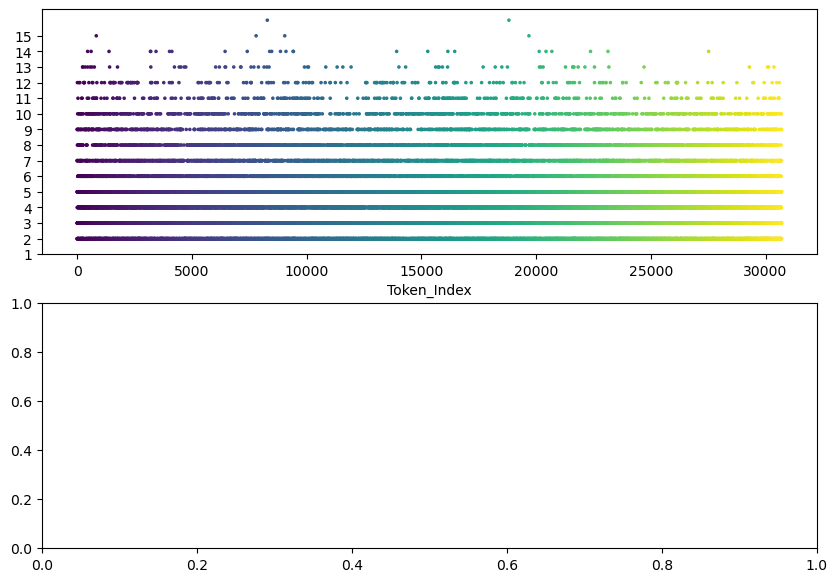

In [98]:
import matplotlib.pyplot as plt

_,axs=plt.subplots(2,1,figsize=(10,7))
axs[0].scatter(range(nword),char_counts,marker='.',s=10,c=np.linspace(.1,.9,len(char_counts)))
axs[0].set(yticks=range(1,int(np.max(char_counts))),xlabel='Token_Index')

In [130]:
encoder(["My","Name","Is","Abhishek"],word2idx)
decoder([4590, 4590, 4590, 4590],idx2word)

'<UNK> <UNK> <UNK> <UNK>'

In [3]:
text="My name is Abhishek"


orig_text=set(text)
print(orig_text)

{' ', 'n', 'M', 'h', 'A', 'm', 's', 'e', 'i', 'y', 'k', 'a', 'b'}


In [2]:
import numpy as np
text="My name is Abhishek"


orig_text=list(set(text))
orig_text.sort()
vocab={word:i for i,word in enumerate(orig_text)}
for i in orig_text:
    print(f'{i} appeared {text.count(i)} times')
print(vocab)

  appeared 3 times
A appeared 1 times
M appeared 1 times
a appeared 1 times
b appeared 1 times
e appeared 2 times
h appeared 2 times
i appeared 2 times
k appeared 1 times
m appeared 1 times
n appeared 1 times
s appeared 2 times
y appeared 1 times
{' ': 0, 'A': 1, 'M': 2, 'a': 3, 'b': 4, 'e': 5, 'h': 6, 'i': 7, 'k': 8, 'm': 9, 'n': 10, 's': 11, 'y': 12}


In [3]:
new_text=list(text)
print(new_text)
token_pair={}
for i in range(len(new_text)-1):
    pair=text[i]+text[i+1]

    if pair not in token_pair:
        token_pair[pair]=1
    else:
        token_pair[pair]+=1
token_pair



['M', 'y', ' ', 'n', 'a', 'm', 'e', ' ', 'i', 's', ' ', 'A', 'b', 'h', 'i', 's', 'h', 'e', 'k']


{'My': 1,
 'y ': 1,
 ' n': 1,
 'na': 1,
 'am': 1,
 'me': 1,
 'e ': 1,
 ' i': 1,
 'is': 2,
 's ': 1,
 ' A': 1,
 'Ab': 1,
 'bh': 1,
 'hi': 1,
 'sh': 1,
 'he': 1,
 'ek': 1}

In [4]:
most_freq_idx=np.argmax(list(token_pair.values()))
most_freqpair_char=list(token_pair.keys())[most_freq_idx]
print(f'Most frequent pair is "{most_freqpair_char}" which appears {list(token_pair.values())[most_freq_idx]} times')

Most frequent pair is "is" which appears 2 times


In [5]:
vocab[most_freqpair_char]=max(vocab.values())+1
vocab

{' ': 0,
 'A': 1,
 'M': 2,
 'a': 3,
 'b': 4,
 'e': 5,
 'h': 6,
 'i': 7,
 'k': 8,
 'm': 9,
 'n': 10,
 's': 11,
 'y': 12,
 'is': 13}

In [6]:
updated_text=[]
i=0
while i<(len(new_text)-1):
    if (new_text[i]+new_text[i+1]) == most_freqpair_char:
        updated_text.append(most_freqpair_char)
        i+=2
    else:
        updated_text.append(new_text[i])
        i+=1

print(len(new_text))
print(len(updated_text))
new_text

19
16


['M',
 'y',
 ' ',
 'n',
 'a',
 'm',
 'e',
 ' ',
 'i',
 's',
 ' ',
 'A',
 'b',
 'h',
 'i',
 's',
 'h',
 'e',
 'k']

In [8]:
print(new_text)

def get_pair_stats(text2pair):
    token_pair={}
    for i in range(len(text2pair)-1):
        pair=text2pair[i]+text2pair[i+1]

        if pair not in token_pair:
            token_pair[pair]=1
        else:
            token_pair[pair]+=1
    return token_pair

token_pair=get_pair_stats(orig_text)
            

['M', 'y', ' ', 'n', 'a', 'm', 'e', ' ', 'i', 's', ' ', 'A', 'b', 'h', 'i', 's', 'h', 'e', 'k']


In [ ]:
def update_vocab(vocab,token_pair):
    idx=np.argmax(list(token_pair.values()))
    most_freqpair_char=list(token_pair.keys())[idx]
    vocab[most_freqpair_char]=max(vocab.values())+1
    return vocab,most_freqpair_char




In [10]:
def generate_new_token_sequence(text,most_freqpair_char):
    new_text=[]
    i=0
    while(i<len(text)-1):
        if (text[i]+text[i+1])==most_freqpair_char:
            new_text.append(most_freqpair_char)
            i+=2
        else:
            new_text.append(text[i])
            i+=1
    return new_text

